# Q8.
```{admonition}
:class: note
Create a plot displaying the test error resulting from random forests on the `Boston` data set for a more comprehensive range of values for `max_features` and `n_estimators`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from ISLP import bart, load_data
from ISLP.models import ModelSpec as MS

In [ ]:
carseats = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Carseats.csv')
carseats[['Urban','US']] = carseats[['Urban','US']] == 'Yes'
carseat_shelve_dummy = pd.get_dummies(carseats['ShelveLoc'],prefix='Shelve')
carseats = carseats.drop(columns='ShelveLoc')
carseats = carseats.join(carseat_shelve_dummy)

In [9]:
carseats.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [10]:
carseats.sample(3)

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,Shelve_Bad,Shelve_Good,Shelve_Medium
92,4.53,114,113,0,97,125,29,12,True,False,False,False,True
354,5.30,133,31,1,80,145,42,18,True,True,False,False,True
259,5.12,123,36,10,467,100,74,11,False,True,True,False,False


### (a)
```{admonition}
:class: note
Split the data set into a training and test set.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(carseats.iloc[:,1:],carseats.iloc[:,0],random_state=1728,test_size=0.3,shuffle=True)
feature_count = X_train.shape[1]
features = X_train.columns

### (b)
```{admonition}
:class: note
Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

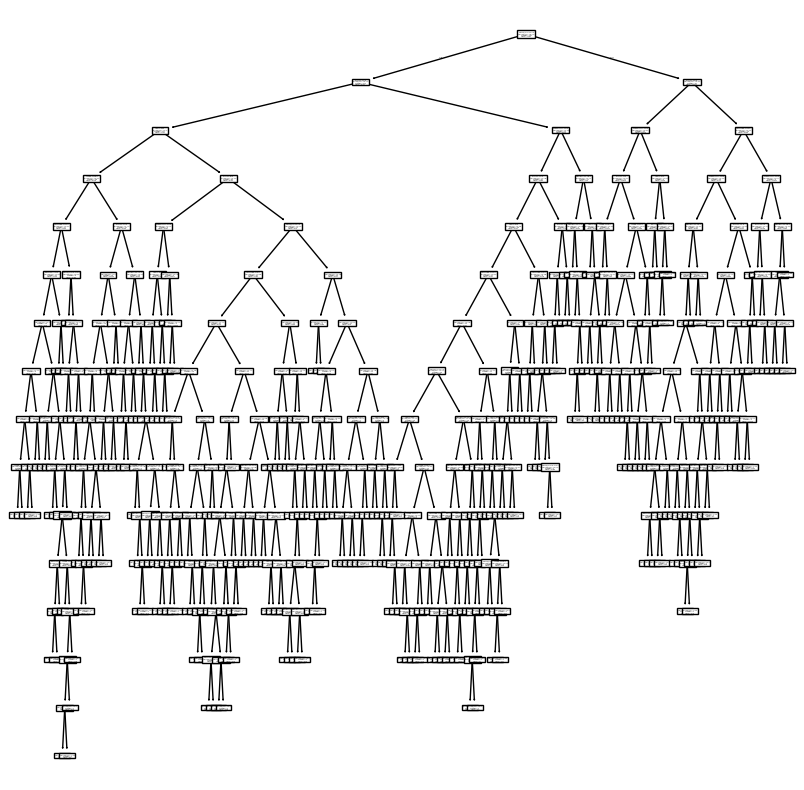

In [12]:
ax = plt.subplots(figsize=(10,10))[1]
rt = DecisionTreeRegressor(criterion='squared_error')
rt.fit(X_train,y_train)
plot_tree(rt,ax=ax,feature_names=features)
plt.show()

In [13]:
test_MSE = mean_squared_error(rt.predict(X_test),y_test)
tree_depth = rt.get_depth()
print(f'Test MSE is {test_MSE:.4f}')
print(f'Tree depth: {tree_depth}')

Test MSE is 5.6732
Tree depth: 15


### (c)
```{admonition}
:class: note
Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [14]:
outer_cv = KFold(10,shuffle=True,random_state=1729)
inner_cv = KFold(10,shuffle=True,random_state=1729)

rtr = DecisionTreeRegressor(criterion='squared_error')

grid = GridSearchCV(rt,param_grid={'max_depth':np.arange(1,17)},cv=inner_cv,scoring='neg_mean_squared_error',n_jobs=-1)
outer_cv_score = -np.mean(cross_val_score(grid,X_train,y_train,cv=outer_cv,scoring='neg_mean_squared_error'))
grid.fit(X_train,y_train)

best_tree = grid.best_estimator_
best_tree_depth = best_tree.get_depth()
test_MSE_best = mean_squared_error(best_tree.predict(X_test),y_test)

print(f'Nested CV test prediction: {outer_cv_score}')
print(f'Cross validation chose depth of {best_tree_depth} giving test MSE {test_MSE_best}')

Nested CV test prediction: 4.337862875705693
Cross validation chose depth of 7 giving test MSE 5.461462200443877


### (d)
```{admonition}
:class: note
Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the `feature_importance_` values to determine which variables are most important.

In [15]:
rfrb = RandomForestRegressor(max_features=feature_count,n_jobs=-1)
rfrb.fit(X_train,y_train)

test_MSE_bagging = mean_squared_error(rfrb.predict(X_test),y_test)
feature_importance_bagging = list(zip(features,rfrb.feature_importances_))
feature_importance_bagging.sort(key=lambda x: -x[1])
print(f'Test MSE is {test_MSE_bagging}')
for feat,importance in feature_importance_bagging:
    print(f'{feat} has importance value {importance:.4f}')

Test MSE is 2.993745735
Shelve_Good has importance value 0.3261
Price has importance value 0.2552
CompPrice has importance value 0.1000
Age has importance value 0.0763
Advertising has importance value 0.0626
Income has importance value 0.0541
Population has importance value 0.0355
Education has importance value 0.0314
Shelve_Bad has importance value 0.0284
Shelve_Medium has importance value 0.0210
Urban has importance value 0.0050
US has importance value 0.0043


### (e)
```{admonition}
:class: note
Use random forests to analyze this data. What test MSE do you obtain? Use the `feature_importance_` values to determine which variables are most important. Describe the effect of $m$, the number of variables considered at each split, on the error rate obtained.

In [16]:
errors_j = {}
best_MSE = np.inf
best_model = None
for j in [1,np.sqrt(feature_count).astype(int),feature_count//3,10,feature_count,50,100,200,500]:
    errors = []
    for i in range(1,feature_count+1):
        rfr_i = RandomForestRegressor(n_estimators=j,max_features=i,n_jobs=-1,random_state=1728,warm_start=True)
        rfr_i.fit(X_train,y_train)
        test_MSE_rfr_i = mean_squared_error(rfr_i.predict(X_test),y_test)
        if test_MSE_rfr_i < best_MSE:
            best_MSE = test_MSE_rfr_i
            best_model = rfr_i
        errors.append(test_MSE_rfr_i)
    errors_j[j] = errors

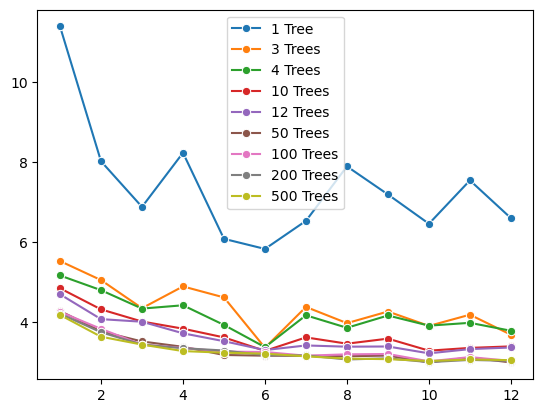

In [17]:
sns.lineplot(x=np.arange(1,feature_count+1),y=errors_j[1],marker='o',label='1 Tree')
for j in errors_j:
    if j == 1:
        continue
    sns.lineplot(x=np.arange(1,feature_count+1),y=errors_j[j],marker='o',label=f'{j} Trees')
plt.legend()
plt.show()

### (f)
```{admonition}
:class: note
Now analyze the data using BART, and report your results.

In [18]:
b_carseat = load_data('Carseats')
A = MS(b_carseat.drop(columns='Sales'),intercept='False').fit_transform(b_carseat)

Xx_train, Xx_test, yx_train, yx_test = train_test_split(np.asarray(A),b_carseat['Sales'],random_state=1728,test_size=0.3,shuffle=True)

bart_carseat = bart.BART(random_state=1728,burnin=100,ndraw=500)
bart_carseat.fit(Xx_train,yx_train)

,num_trees,200
,num_particles,10
,max_stages,5000
,split_prob,<function BAR...0024F8DB85EE0>
,min_depth,0
,std_scale,2
,split_prior,None
,ndraw,500
,burnin,100
,sigma_prior,"(5, ...)"
,num_quantile,50


In [19]:
print(mean_squared_error(bart_carseat.predict(Xx_test),yx_test))

1.6268579572465791
